# 01 — Exploratory Data Analysis (EDA)

This notebook loads the raw training data and explores:
- Feature distributions
- Class balance
- Missing values
- Categorical/numerical breakdown


### Load libraries and raw training dataset


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

df = pd.read_csv("../data/raw/train_updated.csv")
df.head()

,ProfileID,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,QualificationLevel,WorkCategory,RelationshipStatus,OwnsProperty,FamilyObligation,FundUseCase,JointApplicant,RiskFlag
0,DRIRC89L0T,18,137576,209136,846,26,2,10.470,60,0.810,High School,Self-employed,Single,Yes,No,Business,No,0
1,TS0FIUNHNU,47,57194,5970,748,30,2,19.720,36,0.730,High School,Unemployed,Divorced,No,Yes,Education,No,0
2,I0YR284A1V,26,84328,95065,453,7,2,24.250,12,0.450,Master's,Self-employed,Married,No,No,Other,Yes,0
3,WB1T7NQV8A,53,49795,229582,533,107,3,14.440,60,0.170,Bachelor's,Self-employed,Single,Yes,No,Auto,Yes,1
4,J6GU9M4G1Z,49,115450,22072,840,0,4,24.480,12,0.110,Bachelor's,Part-time,Single,No,Yes,Education,Yes,0


### Check dataset shape, data types, and missing values


In [13]:
print("Shape:", df.shape)
df.info()
df.isnull().sum()


Shape: (204277, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204277 entries, 0 to 204276
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ProfileID           204277 non-null  object 
 1   ApplicantYears      204277 non-null  int64  
 2   AnnualEarnings      204277 non-null  int64  
 3   RequestedSum        204277 non-null  int64  
 4   TrustMetric         204277 non-null  int64  
 5   WorkDuration        204277 non-null  int64  
 6   ActiveAccounts      204277 non-null  int64  
 7   OfferRate           204277 non-null  float64
 8   RepayPeriod         204277 non-null  int64  
 9   DebtFactor          204277 non-null  float64
 10  QualificationLevel  204277 non-null  object 
 11  WorkCategory        204277 non-null  object 
 12  RelationshipStatus  204277 non-null  object 
 13  OwnsProperty        204277 non-null  object 
 14  FamilyObligation    204277 non-null  object 
 15  FundUseCase   

ProfileID             0
ApplicantYears        0
AnnualEarnings        0
RequestedSum          0
TrustMetric           0
WorkDuration          0
ActiveAccounts        0
OfferRate             0
RepayPeriod           0
DebtFactor            0
QualificationLevel    0
WorkCategory          0
RelationshipStatus    0
OwnsProperty          0
FamilyObligation      0
FundUseCase           0
JointApplicant        0
RiskFlag              0
dtype: int64

### Compute class proportions for RiskFlag

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("../data/raw/train_updated.csv")
train_df.head()

,ProfileID,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,QualificationLevel,WorkCategory,RelationshipStatus,OwnsProperty,FamilyObligation,FundUseCase,JointApplicant,RiskFlag
0,DRIRC89L0T,18,137576,209136,846,26,2,10.47,60,0.81,High School,Self-employed,Single,Yes,No,Business,No,0
1,TS0FIUNHNU,47,57194,5970,748,30,2,19.72,36,0.73,High School,Unemployed,Divorced,No,Yes,Education,No,0
2,I0YR284A1V,26,84328,95065,453,7,2,24.25,12,0.45,Master's,Self-employed,Married,No,No,Other,Yes,0
3,WB1T7NQV8A,53,49795,229582,533,107,3,14.44,60,0.17,Bachelor's,Self-employed,Single,Yes,No,Auto,Yes,1
4,J6GU9M4G1Z,49,115450,22072,840,0,4,24.48,12,0.11,Bachelor's,Part-time,Single,No,Yes,Education,Yes,0


In [18]:
df['RiskFlag'].value_counts(normalize=True) * 100


RiskFlag
0   88.372
1   11.628
Name: proportion, dtype: float64

### Visualize class imbalance of RiskFlag

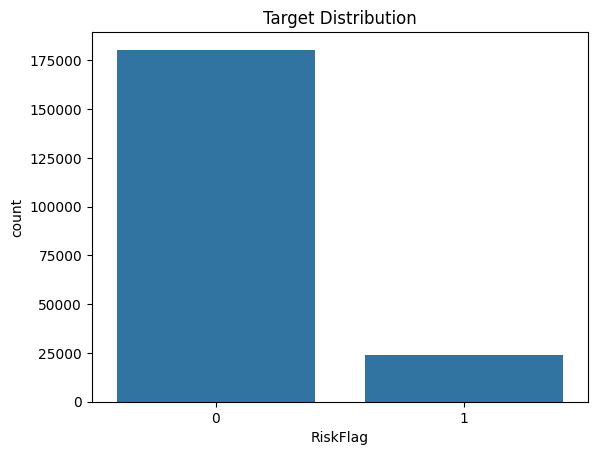

In [19]:
sns.countplot(data=df, x='RiskFlag')
plt.title("Target Distribution")
plt.show()

### Visualize numerical feature distributions (histograms)


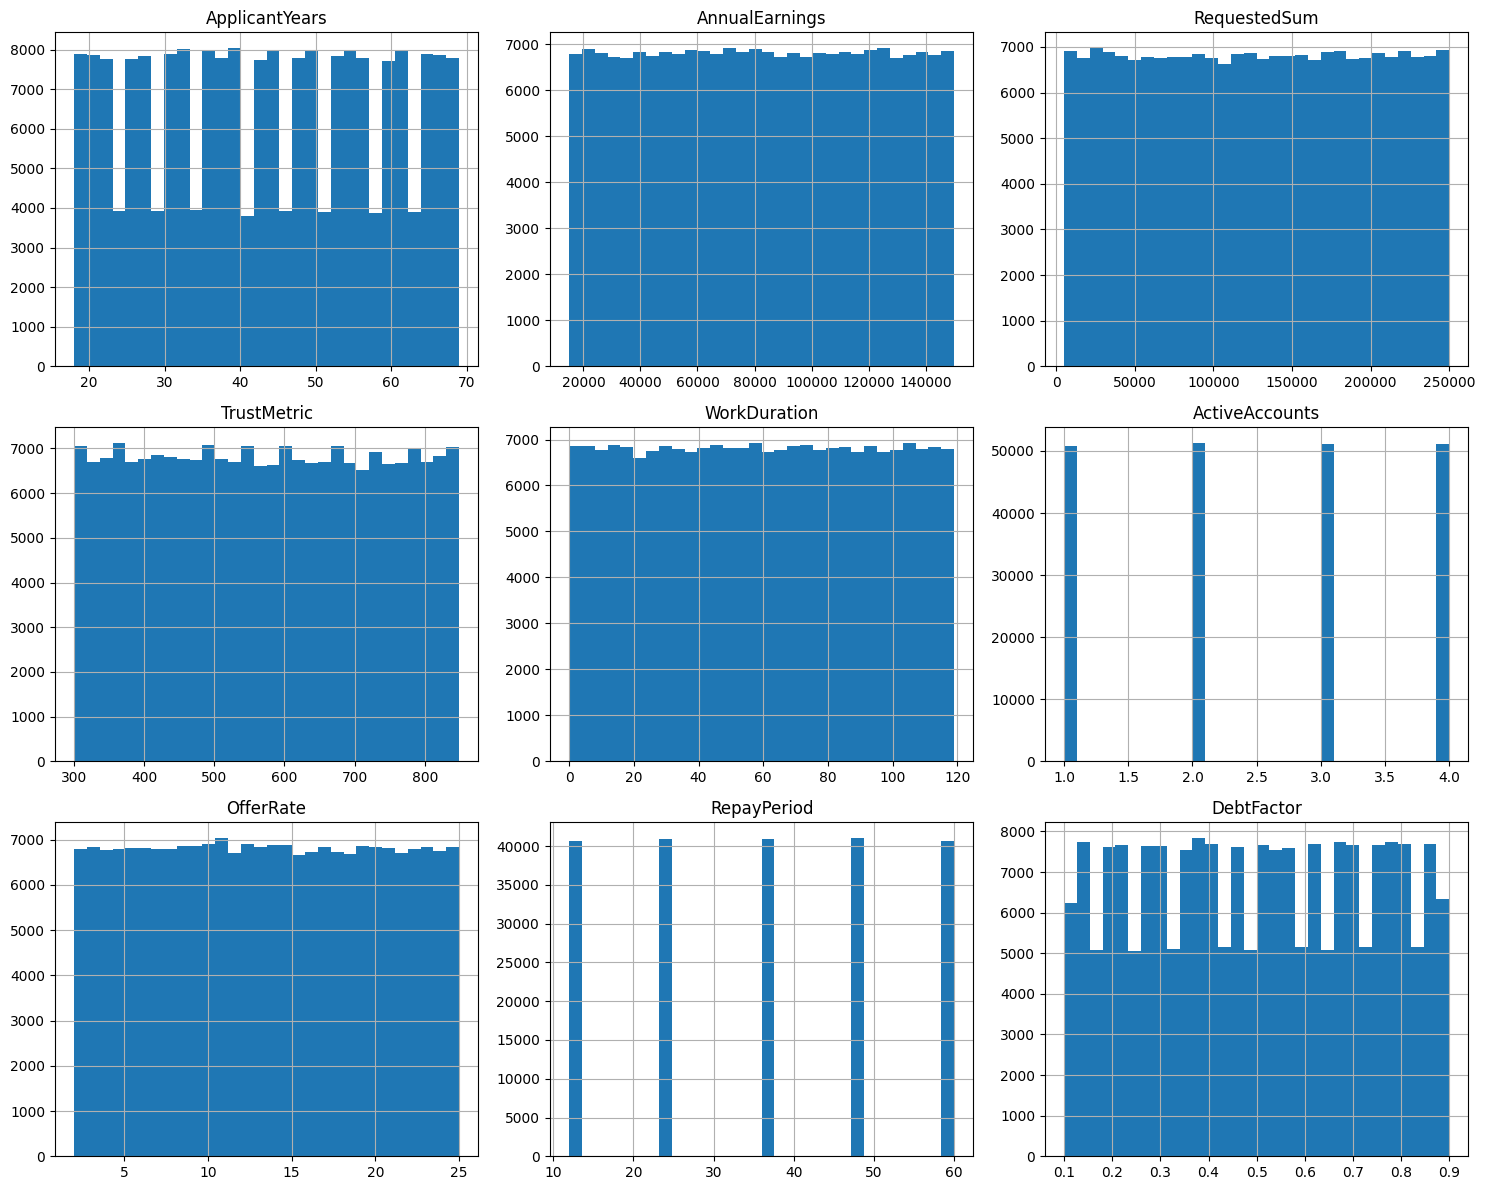

In [20]:
numerical = [
    "ApplicantYears", "AnnualEarnings", "RequestedSum", "TrustMetric",
    "WorkDuration", "ActiveAccounts", "OfferRate", "RepayPeriod", "DebtFactor"
]

df[numerical].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()


### Display category values for each categorical feature

In [21]:
categorical = [
    "QualificationLevel",
    "WorkCategory",
    "RelationshipStatus",
    "FundUseCase"
]

for col in categorical:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- QualificationLevel ---
['High School' "Master's" "Bachelor's" 'PhD']

--- WorkCategory ---
['Self-employed' 'Unemployed' 'Part-time' 'Full-time']

--- RelationshipStatus ---
['Single' 'Divorced' 'Married']

--- FundUseCase ---
['Business' 'Education' 'Other' 'Auto' 'Home']



### Plot frequency distribution of categorical features

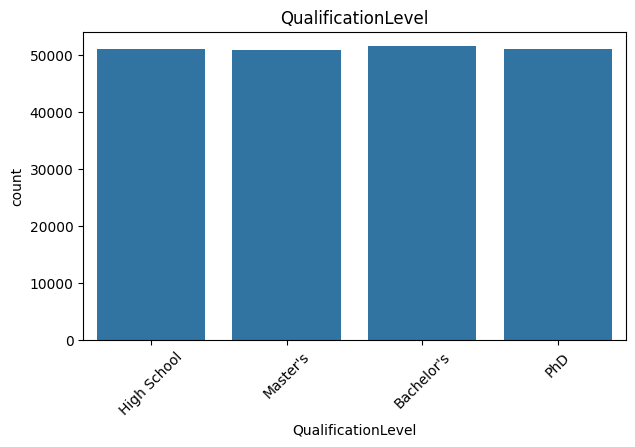

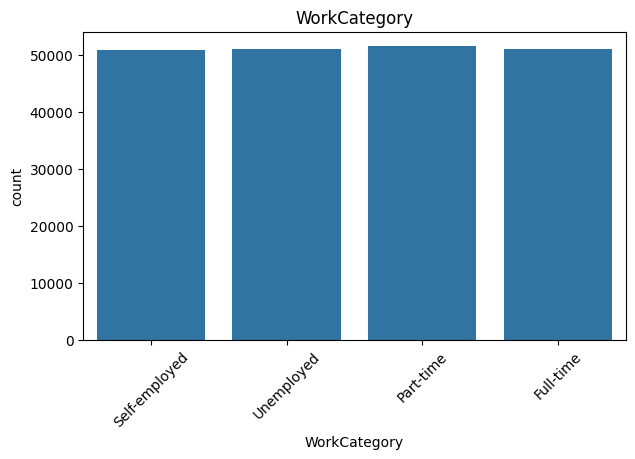

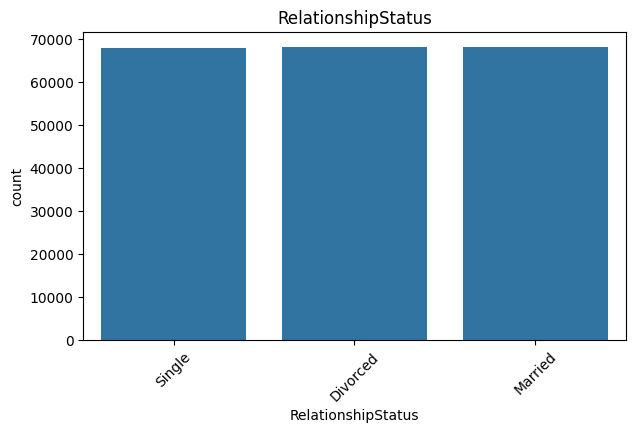

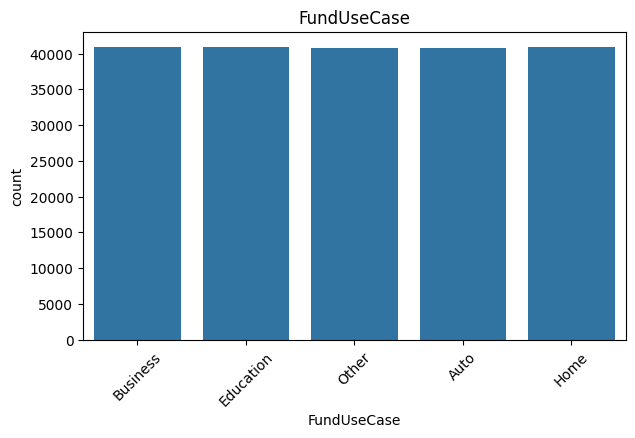

In [22]:
for col in categorical:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

### Compare RiskFlag across categories

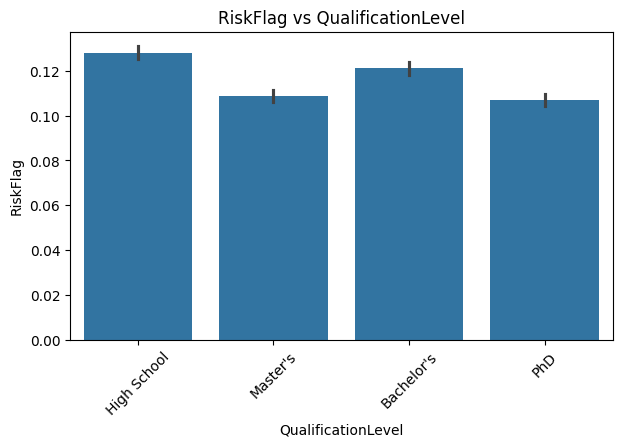

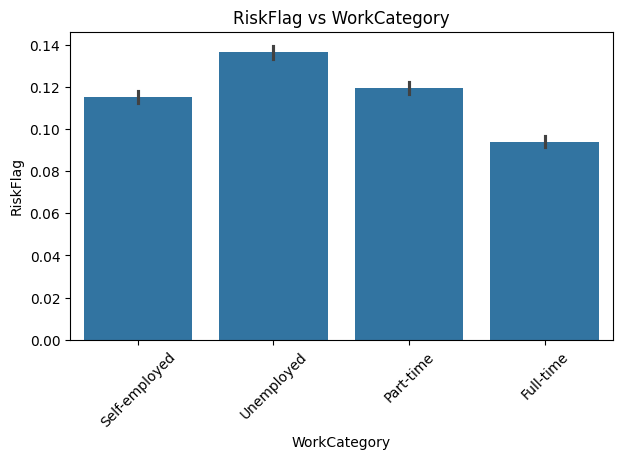

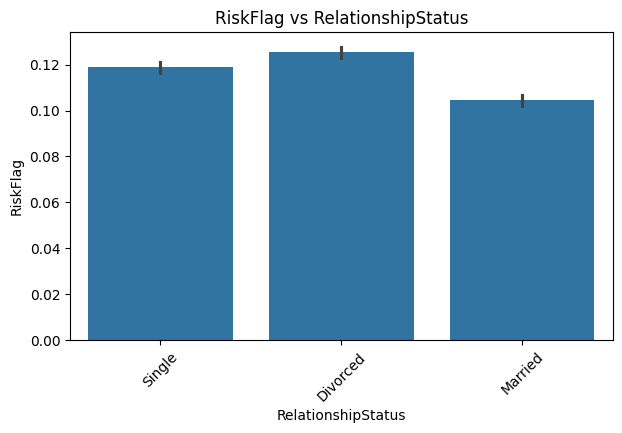

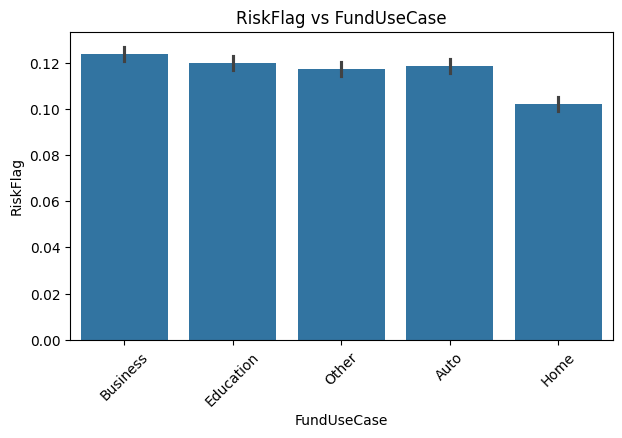

In [23]:
for col in categorical:
    plt.figure(figsize=(7,4))
    sns.barplot(data=df, x=col, y="RiskFlag")
    plt.xticks(rotation=45)
    plt.title(f"RiskFlag vs {col}")
    plt.show()